In [1]:
import joblib
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from missingpy import MissForest
from torch.utils.data import DataLoader

import config
from nn_utils.dataset import preprocess, load_dataset, NeighbourDataset, PointwiseDataset
from nn_utils.trainer import NeighbourAdapter, PointwiseAdapter
from utils.metrics import compute_metrics
from utils.tuning import get_model_class
from utils.plotting import generate_animation

C:\Users\yvjennig\Anaconda3\envs\time_imputation\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\yvjennig\Anaconda3\envs\time_imputation\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\yvjennig\Anaconda3\envs\time_imputation\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle

In [2]:
# Load test indices
test_idx = np.array(json.load(open(f"{config.output_dir_splits}/test_train_split.json"))["test_idx"], dtype=int)

#  Load data
df_true = load_dataset()

# Hide test indices
df = df_true.copy()
df.loc[test_idx, config.parameters] = np.nan

# Load one scaler dict (same scaling for all models)
scaler_dict = joblib.load(f"{config.output_dir_tuning}/mean/scalers.joblib")

# Preprocessing
x_scaled, y_scaled, _ = preprocess(coords=torch.tensor(df[config.coordinates].values),
                                             values=torch.tensor(df[config.parameters].values),
                                             coord_names=config.coordinates,
                                             parameter_names=config.parameters,
                                             cyclic_time=False,
                                             scaler_dict=scaler_dict)

# Scale ground truth
df_true_scaled = df_true.copy()
for i, p in enumerate(config.parameters):
    scaler = scaler_dict[p]
    df_true_scaled[p] = scaler.transform(df_true_scaled[p].values.reshape(-1, 1))

# Assemble model input
X_sklearn = torch.cat([x_scaled, y_scaled], dim=1)


In [3]:
all_model_names = ["remasker", "mean", "mice", "missforest"]  # "remasker" "mlp", , "mastnet"

In [4]:
# Load models
model_dict = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_name in all_model_names:
    # Load meta data   modelmastnet_splitfinal_trial0.json
    with open(f"output/tuning/{model_name}/model{model_name}_splitfinal_trial0.json") as f:
        meta = json.load(f)

    # Load model
    if meta["model_framework"] == "sklearn":
        model = joblib.load(meta["model_path"])
    elif meta["model_framework"] == "pytorch":
        model_class = get_model_class(meta["model_class"].lower())
        model = model_class(**meta["hyps"]["model"])
        model.load_state_dict(torch.load(meta["model_path"], map_location=device, weights_only=True))
        model.to(device)
        model.eval()
    else:
        raise NotImplementedError

    model_dict[model_name] = {"meta": meta, "model": model}

In [ ]:
# model_name = "remasker"
# model = model_dict[model_name]["model"]
#
# y_hat = model.transform(X_sklearn)
# df_y_scaled = pd.DataFrame(y_hat[:, x_scaled.shape[1]:], columns=config.parameters)


In [5]:
# Predict entire dataset and evaluate on test indxs
for model_name, info in model_dict.items():
    print(model_name)

    # Get model
    model = model_dict[model_name]["model"]

    # Predict
    if model_name == "missforest":
        # MissForest does not support separate transform/ loading of models
        valid_hyp_names = ["n_estimators", "max_features"]
        hyps = {k: v for k, v in model_dict["missforest"]["model"].get_params().items() if k in valid_hyp_names}
        y_hat = MissForest(**hyps).fit_transform(X_sklearn.cpu().numpy())
        df_y_scaled = pd.DataFrame(y_hat[:, x_scaled.shape[1]:], columns=config.parameters)

    elif model_name == "mastnet":
        n_neighbours = model_dict[model_name]["meta"]["hyps"]["train"]["n_neighbours"]
        batch_size = model_dict[model_name]["meta"]["hyps"]["train"]["batch_size"]
        y_hat, unc = model.predict(x=x_scaled, y=y_scaled, n_neighbours=n_neighbours, batch_size=batch_size, device=device)
        df_y_scaled = pd.DataFrame(y_hat, columns=config.parameters)

    elif model_name == "mlp":
        batch_size = model_dict[model_name]["meta"]["hyps"]["train"]["batch_size"]
        y_hat, unc = model.predict(x=x_scaled, y=y_scaled, batch_size=batch_size, device=device)
        df_y_scaled = pd.DataFrame(y_hat, columns=config.parameters)

    elif model_name in ["remasker", "mice", "mean", "knn"]:
        y_hat = model.transform(X_sklearn)
        df_y_scaled = pd.DataFrame(y_hat[:, x_scaled.shape[1]:], columns=config.parameters)

    else:
        raise NotImplementedError

    # Add coords to scaled features
    df_y_scaled[config.coordinates] = df[config.coordinates]

    # Features in original units (unscale)
    df_y = df.drop(columns=config.parameters, axis=1)
    for i, p in enumerate(config.parameters):
        df_y[p] = scaler_dict[p].inverse_transform(y_hat[:, i].reshape(-1, 1))

    # Compute metrics (on test idx)
    metrics_scaled = compute_metrics(y_true=df_true_scaled.loc[test_idx, config.parameters].to_numpy(), y_pred=df_y_scaled.loc[test_idx, config.parameters].to_numpy())
    metrics = compute_metrics(y_true=df_true.loc[test_idx, config.parameters].to_numpy(), y_pred=df_y.loc[test_idx, config.parameters].to_numpy())

    model_dict[model_name]["metrics_scaled"] = metrics_scaled
    model_dict[model_name]["metrics"] = metrics
    model_dict[model_name]["df_y_scaled"] = df_y_scaled
    model_dict[model_name]["df_y"] = df_y


remasker


Imputation: 100%|██████████| 637390/637390 [2:18:37<00:00, 76.63it/s]   


mean
mice
missforest
Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8


In [6]:
# Mean errors
for model_name in all_model_names:
    out_str = ""
    for metric_name, metric_val in model_dict[model_name]["metrics_scaled"]["Global"].items():
        out_str = out_str + f"{metric_name}: {metric_val:.4f}  "

    print(f"{model_name:10} {out_str}")

remasker   MAE: 0.0920  RMSE: 0.1249  NRMSE: 0.4374  PCC: 0.9405  R2: 0.8665  KGE: 0.8627  OI: 0.8807  
mean       MAE: 0.0761  RMSE: 0.1233  NRMSE: 0.3869  PCC: 0.9328  R2: 0.8700  KGE: 0.9012  OI: 0.8832  
mice       MAE: 0.0851  RMSE: 0.1281  NRMSE: 0.3767  PCC: 0.9295  R2: 0.8596  KGE: 0.9293  OI: 0.8759  
missforest MAE: 0.0145  RMSE: 0.0296  NRMSE: 0.0868  PCC: 0.9963  R2: 0.9925  KGE: 0.9941  OI: 0.9838  


# Plots

In [7]:
# Build an error table
df_err = pd.concat(
    [
        (
            (df_true_scaled.loc[test_idx, config.parameters] - info["df_y_scaled"].loc[test_idx, config.parameters])
            .abs()
            .stack()
            .rename("error")
            .reset_index(level=1)
            .assign(model=model_name)
        )
        for model_name, info in model_dict.items()
    ],
    ignore_index=True
).rename(columns={"level_1": "feature"})

df_err["feature"] = df_err["feature"].map(config.parameter_name_map)
df_err["model"] = df_err["model"].map(config.model_name_map)

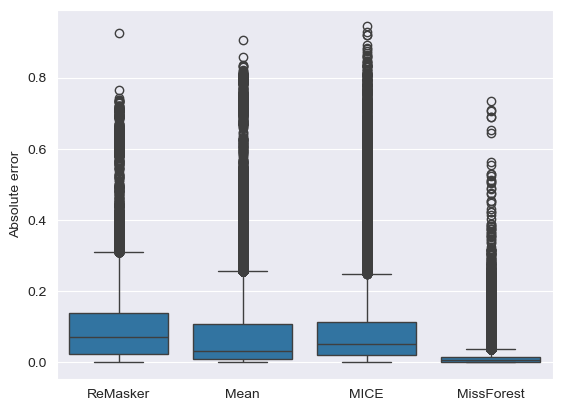

In [8]:
# Error overview
# temp = df_err[df_err["model"].isin(["MissForest", "MaSTNeT"])]
temp = df_err.copy()
sns.boxplot(x=temp["model"], y=temp["error"])
plt.xlabel("")
plt.ylabel("Absolute error")
plt.show()

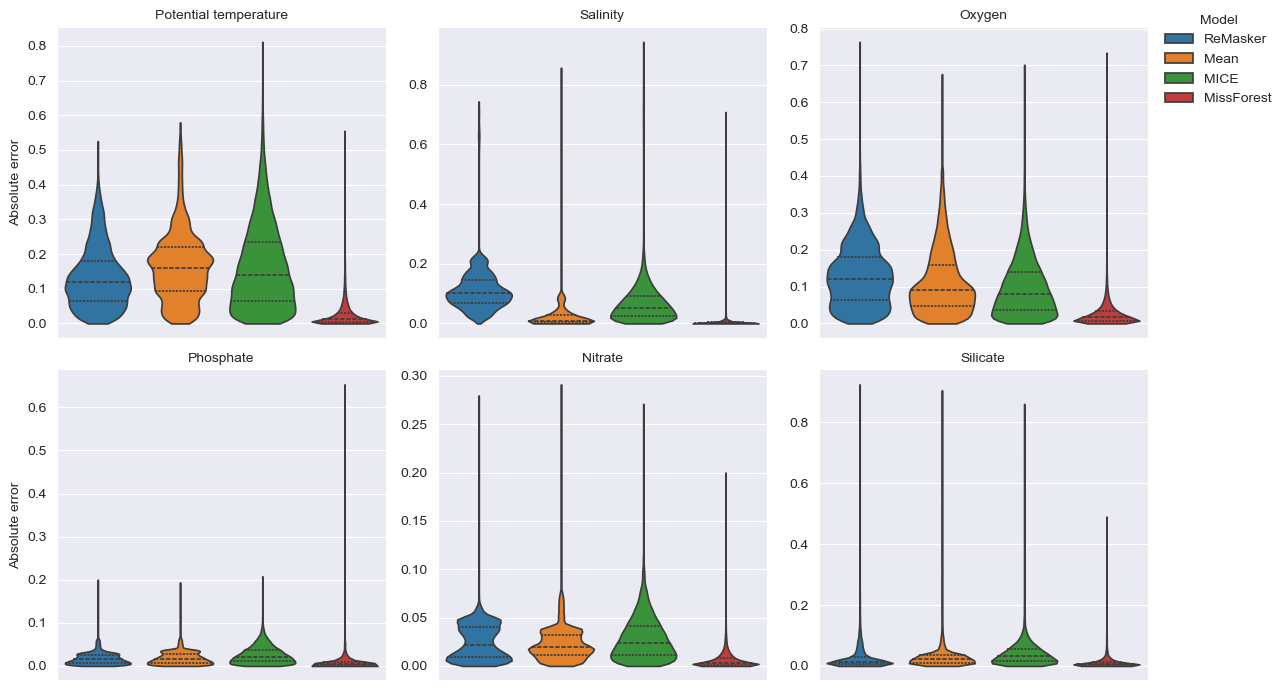

In [9]:
# Violinplot per feature
g = sns.catplot(
    data=df_err,
    x="model",
    y="error",
    col="feature",
    kind="violin",
    col_wrap=3,
    inner="quartile",
    cut=0,
    height=3.5,
    sharey=False,
    hue="model",
    legend=True
)

# Update labels
g.set_titles("{col_name}")
g.set_axis_labels("", "Absolute error")
for ax in g.axes.flatten():
    ax.set_xticklabels([])
    ax.set_xlabel("")

# Move legend outside
g.legend.set_title("Model")
g.legend.set_bbox_to_anchor((1.1, 0.9))
g.legend.set_frame_on(False)

plt.tight_layout()
plt.show()


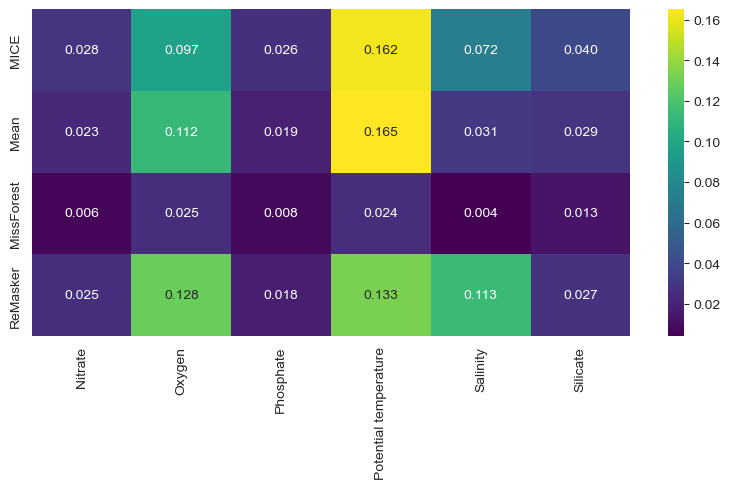

In [10]:
# Heatmap per feature
mean_err = (
    df_err
    .groupby(["model", "feature"])["error"]
    .mean()
    .unstack("feature")
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    mean_err,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()


2.707997260862172


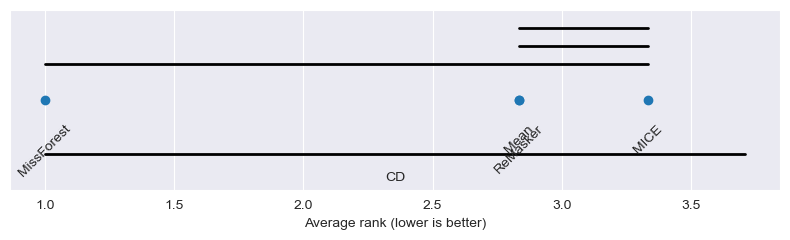

In [11]:
perf = (
    df_err
    .groupby(["model", "feature"])["error"]
    .mean()
    .unstack("feature")
)
ranks = perf.rank(axis=0, ascending=True)


import scikit_posthocs as sp
nemenyi = sp.posthoc_nemenyi_friedman(perf.T.values)
nemenyi.index = perf.index
nemenyi.columns = perf.index

from scipy.stats import studentized_range
import numpy as np

k = perf.shape[0]   # models
N = perf.shape[1]   # features

alpha = 0.05

q_alpha = studentized_range.ppf(1 - alpha, k, np.inf)

CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

print(CD)




avg_ranks = ranks.mean(axis=1)
avg_ranks = avg_ranks.sort_values()

fig, ax = plt.subplots(figsize=(8, 2.5))

y = 1
ax.scatter(avg_ranks.values, [y] * len(avg_ranks), zorder=3)

for i, model in enumerate(avg_ranks.index):
    ax.text(avg_ranks.values[i], y - 0.05, model,
            ha="center", va="top", rotation=45)

# axis
ax.set_yticks([])
ax.set_xlabel("Average rank (lower is better)")
ax.set_ylim(0.8, 1.2)

# ---- significance bars (simple greedy grouping) ----

models = avg_ranks.index.tolist()
rvals = avg_ranks.values

bar_y = 1.08

i = 0
while i < len(rvals):
    j = i
    while j + 1 < len(rvals) and rvals[j + 1] - rvals[i] <= CD:
        j += 1

    if j > i:
        ax.plot([rvals[i], rvals[j]], [bar_y, bar_y], lw=2, color="black")
        bar_y += 0.04

    i += 1

# draw CD scale
xmin = rvals.min()
ax.plot([xmin, xmin + CD], [0.88, 0.88], lw=2, color="black")
ax.text(xmin + CD / 2, 0.84, "CD", ha="center", va="top")

plt.tight_layout()
plt.show()



In [12]:
# Animations
for param in config.parameters:
    # Imputation (replace nan values with predictions)
    df_imputed = df_true.copy()
    df_imputed = df_imputed.combine_first(df_y)
    # df_imputed[config.coordinates] = df[config.coordinates]
    generate_animation(df_imputed, scaler_dict=None, parameter=param, save_as=f"output/testing/{model_name}/model{model_name}_{param}_imputation_{model_name}.mp4")
    #
    # # Reconstruction
    # if model_name == "mastnet" or model_name == "remasker":
    #     df_rec = pd.DataFrame(y_pred, columns=config.parameters)
    #     df_rec[config.coordinates] = df[config.coordinates]
    #     generate_animation(df_rec, scaler_dict=scaler_dict, parameter=param, save_as=f"output/tuning/{model_name}/model{model_name}_{param}_reconstruction_{model_name}.mp4")
    #
    # if variance is not None:
    #     df_variance = pd.DataFrame(variance, columns=config.parameters)
    #     df_variance[config.coordinates] = df[config.coordinates]
    #     generate_animation(df_variance, scaler_dict=None, parameter=param, save_as=f"output/tuning/{model_name}/model{model_name}_{param}_variance_{model_name}.mp4")


Animation saved as output/testing/missforest/modelmissforest_P_TEMPERATURE_imputation_missforest.mp4
Animation saved as output/testing/missforest/modelmissforest_P_SALINITY_imputation_missforest.mp4
Animation saved as output/testing/missforest/modelmissforest_P_OXYGEN_imputation_missforest.mp4
Animation saved as output/testing/missforest/modelmissforest_P_NITRATE_imputation_missforest.mp4
Animation saved as output/testing/missforest/modelmissforest_P_SILICATE_imputation_missforest.mp4
Animation saved as output/testing/missforest/modelmissforest_P_PHOSPHATE_imputation_missforest.mp4
